In [2]:
import torch
from pathlib import Path
from PIL import Image
import random
import os
import numpy as np


In [5]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [6]:
random_seed = 42
batch_size = 16
data_yaml = "data.yaml"
epochs = 100
img_size = 640
device = "cuda" if torch.cuda.is_available() else "cpu"
workers = os.cpu_count() / 2
optimizer = None
lr0 = None
patience = None
augmentations = None

In [7]:
data_dir = Path("../data/TXL-PBC")
images_dir = data_dir / "images"
train_images_dir = data_dir / "images" / "train"

1260
Image shape: (480, 640, 3)


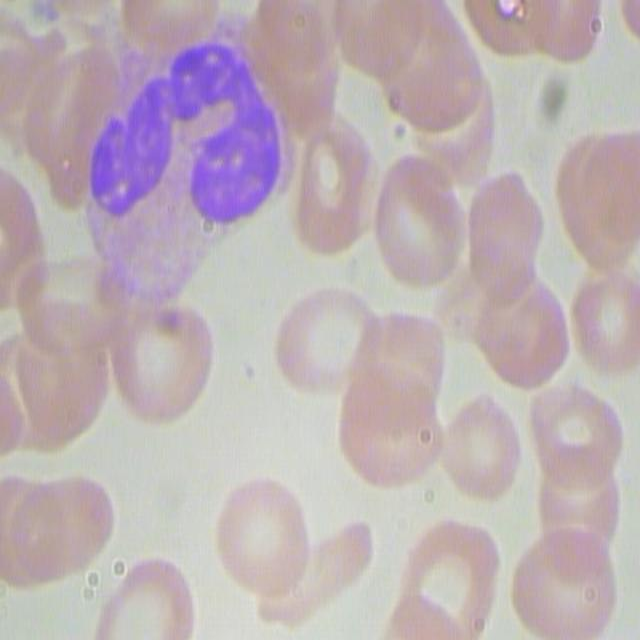

In [5]:
img_paths = list(images_dir.glob("*/*.png"))
print(len(img_paths))
sample_img = img_paths[random.randint(0, len(img_paths) - 1)]
img = Image.open(sample_img)
print(f"Image shape: {np.array(img).shape}")
img.resize(size=(640, 640))

In [6]:
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [7]:
walk_through_dir(images_dir)

There are 3 directories and 0 images in '..\data\TXL-PBC\images'.
There are 0 directories and 126 images in '..\data\TXL-PBC\images\test'.
There are 0 directories and 882 images in '..\data\TXL-PBC\images\train'.
There are 0 directories and 252 images in '..\data\TXL-PBC\images\val'.


In [ ]:
model = YOLO(model="yolo26s.pt", task="detect")
model.to(device)

NameError: name 'YOLO' is not defined

In [9]:
results = model.train(data=data_yaml, epochs=epochs, imgsz=img_size)

Ultralytics 8.4.174  Python-3.14.0 torch-2.14.0+cpu CPU (AMD Ryzen 7 7730U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, optimizer=aut

KeyboardInterrupt: 

In [ ]:
for key, value in results.args.items():
    print(f"{key}: {value}")